# Projeto de Ciência de Dados — Previsão de Preço de Carros Usados
### Notebook único (Partes 1 a 5)

| Parte | Conteúdo | Onde está |
|---|---|---|
| 1 | Definição do problema | markdown abaixo |
| 2 | Arquitetura lógica | markdown abaixo |
| 3 | Modelagem de dados (ETL/ELT) | Etapas 1–9 |
| 4 | Machine Learning | baseline + modelo final |
| 5 | Visualização do resultado | 4 gráficos |

Roda de cima para baixo, do CSV bruto (`used_car_price_prediction_1M.csv`) até os gráficos.


## 1. Definição do Problema

**Contexto.** A precificação de um veículo usado depende de dezenas de variáveis
(idade, quilometragem, marca, motor, histórico, acidentes). Precificar errado gera
perda para o vendedor ou afasta o comprador.

**Objetivo.** Prever o **preço de venda** de um carro usado a partir de suas
características.

**Tipo de problema.** Aprendizado supervisionado de **regressão**.
**Variável alvo:** `Price` (transformada em `Price_log`).

**Pergunta norteadora.** *"Dado um conjunto de atributos, qual o preço justo do veículo?"*

**Critério de sucesso.** Métrica principal **RMSE** (menor = melhor); complementares
**R²** e **MAE**.


## 2. Arquitetura Lógica

```
[CSV bruto] -> [Ingestão] -> [ETL/Limpeza] -> [Feature Engineering]
            -> [Modelagem ML] -> [Visualização]
```

**Fonte de dados.** `used_car_price_prediction_1M.csv` (~1.005.000 linhas × 20 colunas,
Kaggle, com imperfeições intencionais).

**Componentes e tecnologias.** Ingestão e ETL em Python + Pandas/NumPy; armazenamento
intermediário em Parquet; modelagem com scikit-learn; visualização com Matplotlib.

**Recursos.** RAM ≥ 8 GB, CPU quad-core, Python 3.9+.

**Bibliotecas.** `pandas`, `numpy`, `scikit-learn`, `pyarrow`, `matplotlib`.


## 3. Modelagem de Dados (ETL/ELT)

Pipeline em 9 etapas: da leitura do CSV bruto até os splits de treino/teste prontos.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/used_car_price_prediction_1M.csv" /content/

Mounted at /content/drive


In [3]:
# =============================================================================
# Para instalar as dependências, rode no terminal:
#   pip install pandas numpy scikit-learn pyarrow matplotlib
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import os

In [5]:
# =============================================================================
# ETAPA 1 — INGESTÃO E VALIDAÇÃO INICIAL
# Carregamos o arquivo CSV e exibimos informações básicas para entender os dados
# =============================================================================
print("=" * 60)
print("ETAPA 1 — Ingestão e validação inicial")
print("=" * 60)

df = pd.read_csv("used_car_price_prediction_1M.csv")

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores faltantes:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nEstatísticas do target (Price):")
print(df["Price"].describe().apply(lambda x: f"{x:,.2f}"))

ETAPA 1 — Ingestão e validação inicial
Linhas: 1,005,000
Colunas: 20

Tipos de dados:
Brand                object
Model                object
Year                  int64
Mileage_kmpl        float64
Engine_CC           float64
Horsepower          float64
Fuel_Type            object
Transmission         object
Owner_Type           object
Color                object
City                 object
Kms_Driven            int64
Insurance_Valid       int64
Service_History       int64
Accidents             int64
Tax_Paid              int64
Number_of_Doors       int64
Seats                 int64
Registration_Age      int64
Price               float64
dtype: object

Valores faltantes:
Mileage_kmpl    80390
Engine_CC       80403
Horsepower      80403
Fuel_Type       78733
Transmission    80385
Color           80419
City            80430
dtype: int64

Estatísticas do target (Price):
count     1,005,000.00
mean      1,012,896.96
std       1,141,644.94
min          50,000.00
25%         343,350.41
50%  

In [6]:
# =============================================================================
# ETAPA 2 — REMOÇÃO DE DUPLICATAS
# Registros idênticos atrapalham o modelo (ele "aprende" o mesmo caso duas vezes)
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 2 — Remoção de duplicatas")
print("=" * 60)

antes = len(df)
df = df.drop_duplicates()
depois = len(df)
print(f"Duplicatas removidas: {antes - depois:,}")
print(f"Registros restantes:  {depois:,}")


ETAPA 2 — Remoção de duplicatas
Duplicatas removidas: 5,000
Registros restantes:  1,000,000


In [7]:
# =============================================================================
# ETAPA 3 — TRATAMENTO DE VALORES FALTANTES
# + ou - 8% dos registros têm valores ausentes em 7 colunas.
# Estratégia: mediana para números (resistente a outliers),
# 'Unknown' para textos (preserva a informação de que estava vazio)
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 3 — Tratamento de valores faltantes")
print("=" * 60)

# Numéricas: preencher com a mediana
numeric_cols = ["Mileage_kmpl", "Engine_CC", "Horsepower"]
for col in numeric_cols:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"{col}: mediana = {mediana:.2f}")

# Categóricas: preencher com 'Unknown'
categorical_missing = ["Fuel_Type", "Transmission", "Color", "City"]
for col in categorical_missing:
    df[col] = df[col].fillna("Unknown")
    print(f"{col}: preenchido com 'Unknown'")

print(f"\nValores faltantes restantes: {df.isnull().sum().sum()}")


ETAPA 3 — Tratamento de valores faltantes
Mileage_kmpl: mediana = 18.00
Engine_CC: mediana = 1500.20
Horsepower: mediana = 120.06
Fuel_Type: preenchido com 'Unknown'
Transmission: preenchido com 'Unknown'
Color: preenchido com 'Unknown'
City: preenchido com 'Unknown'

Valores faltantes restantes: 0


In [8]:
# =============================================================================
# ETAPA 4 — TRATAMENTO DE OUTLIERS E TRANSFORMAÇÃO DO TARGET
# O preço vai de 50 mil a 37,8 milhões — distribuição extremamente assimétrica.
# Solução: transformação logarítmica (log(Price)) que comprime a escala.
# O modelo aprende na escala log; para converter de volta: np.expm1(predição)
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 4 — Transformação do target (Price)")
print("=" * 60)

Q1  = df["Price"].quantile(0.25)
Q3  = df["Price"].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR
outliers = (df["Price"] > limite_superior).sum()
print(f"Outliers extremos detectados (acima de {limite_superior:,.0f}): {outliers:,} ({outliers/len(df)*100:.2f}%)")
print("→ Optamos por manter e usar transformação logarítmica")

df["Price_log"] = np.log1p(df["Price"])
print(f"\nPrice_log — média: {df['Price_log'].mean():.4f}, std: {df['Price_log'].std():.4f}")
print("(distribuição muito mais simétrica agora)")


ETAPA 4 — Transformação do target (Price)
Outliers extremos detectados (acima de 4,144,520): 5,803 (0.58%)
→ Optamos por manter e usar transformação logarítmica

Price_log — média: 13.2783, std: 1.2086
(distribuição muito mais simétrica agora)


In [9]:
# =============================================================================
# ETAPA 5 — PADRONIZAÇÃO DAS VARIÁVEIS CATEGÓRICAS
# O dataset tem erros intencionais: espaços extras, capitalização errada, typos.
# Exemplos encontrados: 'PETROL', ' Diesel', 'hybridd', 'electrik'
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 5 — Padronização de variáveis categóricas")
print("=" * 60)

# Padronizar todas as colunas de texto
text_cols = ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Corrigir erros tipográficos identificados na análise
correcoes = {
    "Fuel_Type": {
        "Hybridd":  "Hybrid",
        "Electrik": "Electric",
        "Cng":      "CNG",
    }
}
for col, mapa in correcoes.items():
    df[col] = df[col].replace(mapa)
    print(f"{col}: {len(mapa)} correções aplicadas → {sorted(df[col].unique())}")


ETAPA 5 — Padronização de variáveis categóricas
Fuel_Type: 3 correções aplicadas → ['CNG', 'Diesel', 'Electric', 'Hybrid', 'Petrol', 'Unknown']


In [10]:
# =============================================================================
# ETAPA 6 — FEATURE ENGINEERING (Engenharia de Features)
# Criamos novas variáveis que podem ajudar o modelo a aprender melhor.
# Cada nova feature captura uma relação que não estava explícita nos dados.
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 6 — Feature Engineering")
print("=" * 60)

# Idade real do veículo (mais intuitivo que Registration_Age)
df["Vehicle_Age"] = 2025 - df["Year"]
print("✓ Vehicle_Age: idade do veículo em anos")

# Indicador de marca premium (veículos de luxo têm precificação diferente)
marcas_premium = ["Bmw", "Mercedes", "Audi", "Porsche", "Jaguar", "Land Rover", "Volvo", "Lexus"]
df["Is_Premium"] = df["Brand"].isin(marcas_premium).astype(int)
print(f"✓ Is_Premium: {df['Is_Premium'].sum():,} veículos premium ({df['Is_Premium'].mean()*100:.1f}%)")

# Potência por cilindrada: mede eficiência mecânica do motor
df["Power_per_CC"] = df["Horsepower"] / (df["Engine_CC"] + 1)
print(f"✓ Power_per_CC: média = {df['Power_per_CC'].mean():.4f}")

# Quilometragem por ano: uso anual médio (quilômetro/ano)
df["Kms_per_Year"] = df["Kms_Driven"] / (df["Vehicle_Age"] + 1)
print(f"✓ Kms_per_Year: média = {df['Kms_per_Year'].mean():,.0f} km/ano")

# Score de confiabilidade: combina seguros, histórico e acidentes
df["Reliability_Score"] = (
    df["Insurance_Valid"] +
    df["Service_History"] +
    df["Tax_Paid"]        -
    df["Accidents"]
)
print(f"✓ Reliability_Score: varia de {df['Reliability_Score'].min()} a {df['Reliability_Score'].max()}")


ETAPA 6 — Feature Engineering
✓ Vehicle_Age: idade do veículo em anos
✓ Is_Premium: 231,044 veículos premium (23.1%)
✓ Power_per_CC: média = 0.0804
✓ Kms_per_Year: média = 13,819 km/ano
✓ Reliability_Score: varia de -4 a 3


In [11]:
# =============================================================================
# ETAPA 7 — ENCODING DAS VARIÁVEIS CATEGÓRICAS
# Algoritmos de ML só entendem números. Precisamos converter texto em números.
#
# Duas estratégias:
# - One-Hot Encoding (OHE): para colunas com poucas categorias (ex: Fuel_Type)
# - Label Encoding: para colunas com muitas categorias (ex: Brand, Model)
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 7 — Encoding de variáveis categóricas")
print("=" * 60)

# One-Hot Encoding: baixa cardinalidade
ohe_cols = ["Fuel_Type", "Transmission", "Owner_Type"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f"✓ OHE aplicado em: {ohe_cols}")

# Label Encoding: alta cardinalidade
label_encoders = {}
le_cols = ["Brand", "Model", "City", "Color"]
for col in le_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    df = df.drop(columns=[col])
print(f"✓ Label Encoding aplicado em: {le_cols}")

# Remover colunas redundantes ou desnecessárias
df = df.drop(columns=["Year", "Registration_Age", "Price"])
print(f"\nShape final: {df.shape}")
print(f"Colunas: {list(df.columns)}")


ETAPA 7 — Encoding de variáveis categóricas
✓ OHE aplicado em: ['Fuel_Type', 'Transmission', 'Owner_Type']
✓ Label Encoding aplicado em: ['Brand', 'Model', 'City', 'Color']

Shape final: (1000000, 30)
Colunas: ['Mileage_kmpl', 'Engine_CC', 'Horsepower', 'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents', 'Tax_Paid', 'Number_of_Doors', 'Seats', 'Price_log', 'Vehicle_Age', 'Is_Premium', 'Power_per_CC', 'Kms_per_Year', 'Reliability_Score', 'Fuel_Type_Diesel', 'Fuel_Type_Electric', 'Fuel_Type_Hybrid', 'Fuel_Type_Petrol', 'Fuel_Type_Unknown', 'Transmission_Manual', 'Transmission_Unknown', 'Owner_Type_Fourth+', 'Owner_Type_Second', 'Owner_Type_Third', 'Brand_enc', 'Model_enc', 'City_enc', 'Color_enc']


In [12]:
# =============================================================================
# ETAPA 8 — DIVISÃO TREINO / TESTE
# 80% treino / 20% teste. random_state=42 garante reprodutibilidade.
# =============================================================================
print("\n" + "=" * 60)
print("ETAPA 8 — Divisão treino / teste")
print("=" * 60)

X = df.drop(columns=["Price_log"])   # features (entradas)
y = df["Price_log"]                  # target (saída)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {len(X_train):,} registros (80%)")
print(f"Teste:  {len(X_test):,} registros (20%)")
print(f"Features: {X.shape[1]}")


ETAPA 8 — Divisão treino / teste
Treino: 800,000 registros (80%)
Teste:  200,000 registros (20%)
Features: 29


In [13]:
# =============================================================================
# ETAPA 9 — EXPORTAR DADOS PROCESSADOS (opcional)
# Mantido para reprodutibilidade. Como este notebook segue direto para o ML,
# as etapas 4 e 5 usam as variáveis já em memória — não precisa recarregar.
# =============================================================================
df.to_parquet("data_processed.parquet", index=False)
with open("train_test_split.pkl", "wb") as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)
print("✓ data_processed.parquet e train_test_split.pkl salvos")

✓ data_processed.parquet e train_test_split.pkl salvos


## 4. Machine Learning

Usamos os splits já criados na **Etapa 8** (em memória — sem recarregar arquivo).

- **Baseline:** `LinearRegression` (referência simples).
- **Modelo final:** `HistGradientBoostingRegressor` (gradient boosting do scikit-learn,
  rápido em 1M de linhas, capta relações não-lineares).

Toda previsão sai em escala log e é revertida com `np.expm1()`.

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3})
np.random.seed(42)

# splits já vêm da Etapa 8
y_test_real = np.expm1(y_test)   # preço em R$ para métricas interpretáveis
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,} | Features: {X_train.shape[1]}")

Treino: 800,000 | Teste: 200,000 | Features: 29


In [15]:
# --- Baseline: Regressão Linear ---
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin_log = lin.predict(X_test)
pred_lin = np.expm1(pred_lin_log)
print("Baseline treinado.")

Baseline treinado.


In [16]:
# --- Modelo final: HistGradientBoostingRegressor ---
hgb = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.08, max_depth=None, random_state=42)
hgb.fit(X_train, y_train)
pred_hgb_log = hgb.predict(X_test)
pred_hgb = np.expm1(pred_hgb_log)
print("Modelo final treinado.")

Modelo final treinado.


In [17]:
# --- Avaliação: RMSE, MAE, R² (em escala log e em R$) ---
def avaliar(y_log, pred_log):
    y_real, pred_real = np.expm1(y_log), np.expm1(pred_log)
    return {
        "RMSE_log": np.sqrt(mean_squared_error(y_log, pred_log)),
        "MAE_log":  mean_absolute_error(y_log, pred_log),
        "R2_log":   r2_score(y_log, pred_log),
        "RMSE_R$":  np.sqrt(mean_squared_error(y_real, pred_real)),
        "MAE_R$":   mean_absolute_error(y_real, pred_real),
        "R2_real":  r2_score(y_real, pred_real),
    }

resultados = pd.DataFrame({
    "Linear (baseline)":    avaliar(y_test, pred_lin_log),
    "HistGradientBoosting": avaliar(y_test, pred_hgb_log),
}).T
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(resultados)
resultados

                      RMSE_log  MAE_log  R2_log      RMSE_R$       MAE_R$  \
Linear (baseline)       0.7769   0.6172  0.5885 955,199.2262 482,210.9504   
HistGradientBoosting    0.6687   0.5172  0.6952 629,479.0194 355,801.0263   

                      R2_real  
Linear (baseline)      0.3009  
HistGradientBoosting   0.6964  


,RMSE_log,MAE_log,R2_log,RMSE_R$,MAE_R$,R2_real
Linear (baseline),0.7769,0.6172,0.5885,"955,199.2262","482,210.9504",0.3009
HistGradientBoosting,0.6687,0.5172,0.6952,"629,479.0194","355,801.0263",0.6964


## 5. Visualização do Resultado

Quatro gráficos, cada um salvo em `.png` para colar nos slides.

### Gráfico 1 — Previsto vs. Real
Pontos colados na linha vermelha (`y = x`) = boas previsões. Eixos em log por causa
da assimetria do preço.

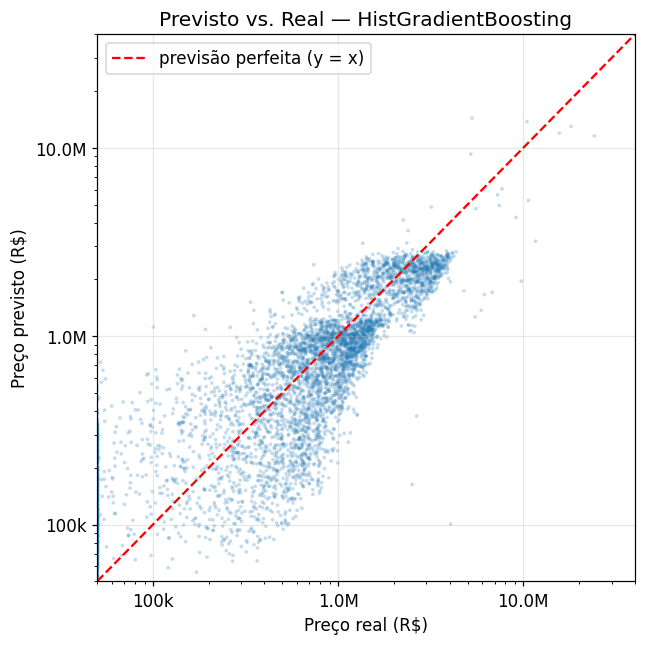

In [18]:
def fmt_brl(x, _):
    return f"{x/1000:.0f}k" if x < 1e6 else f"{x/1e6:.1f}M"

fig, ax = plt.subplots(figsize=(6, 6))
n_amostra = min(5000, len(y_test_real))
idx = np.random.choice(len(y_test_real), n_amostra, replace=False)
ax.scatter(np.asarray(y_test_real)[idx], pred_hgb[idx], s=6, alpha=0.25, edgecolor="none")
lims = [5e4, 4e7]
ax.plot(lims, lims, "r--", lw=1.5, label="previsão perfeita (y = x)")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_brl))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_brl))
ax.set_xlabel("Preço real (R$)"); ax.set_ylabel("Preço previsto (R$)")
ax.set_title("Previsto vs. Real — HistGradientBoosting"); ax.legend()
fig.tight_layout(); fig.savefig("grafico1_previsto_vs_real.png"); plt.show()

### Gráfico 2 — Distribuição dos resíduos
Esperamos um sino centrado em **zero** e simétrico: sem viés sistemático.

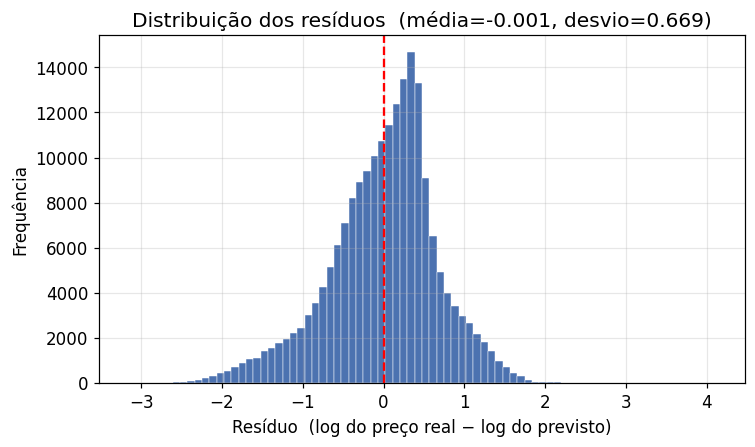

In [19]:
resid = np.asarray(y_test) - pred_hgb_log
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(resid, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.set_xlabel("Resíduo  (log do preço real − log do previsto)")
ax.set_ylabel("Frequência")
ax.set_title(f"Distribuição dos resíduos  (média={resid.mean():.3f}, desvio={resid.std():.3f})")
fig.tight_layout(); fig.savefig("grafico2_residuos.png"); plt.show()

### Gráfico 3 — Importância das features
O `HistGradientBoosting` não tem `feature_importances_` nativo, então usamos
**importância por permutação** (numa subamostra de 5.000 linhas, para ser rápido).

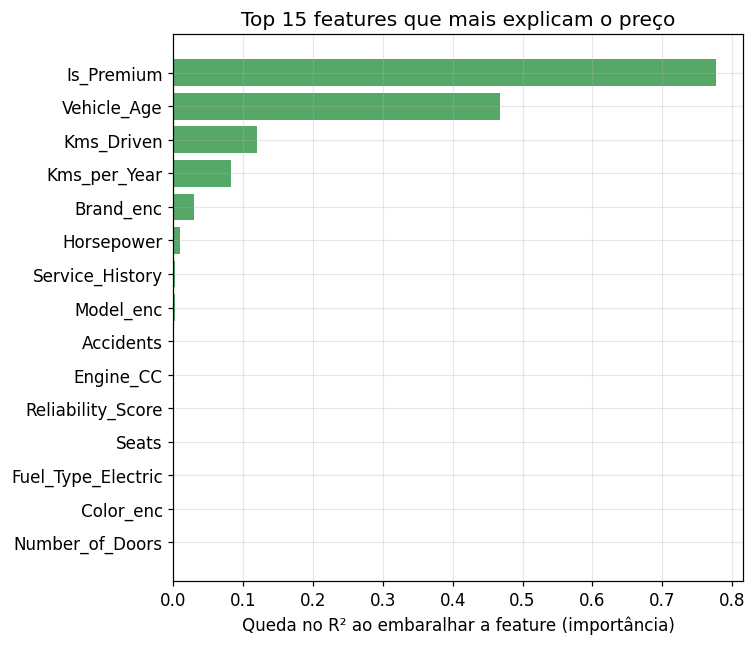

In [20]:
n_sub = min(5000, len(X_test))
sub = np.random.choice(len(X_test), n_sub, replace=False)
pi = permutation_importance(hgb, X_test.iloc[sub], y_test.iloc[sub],
                            n_repeats=5, random_state=42, n_jobs=-1)
top15 = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15.index, top15.values, color="#55A868")
ax.set_xlabel("Queda no R² ao embaralhar a feature (importância)")
ax.set_title("Top 15 features que mais explicam o preço")
fig.tight_layout(); fig.savefig("grafico3_importancia_features.png"); plt.show()

### Gráfico 4 — Baseline vs. Modelo final
Comparação direta: erro em R$ (menor melhor) e R² em log (maior melhor).

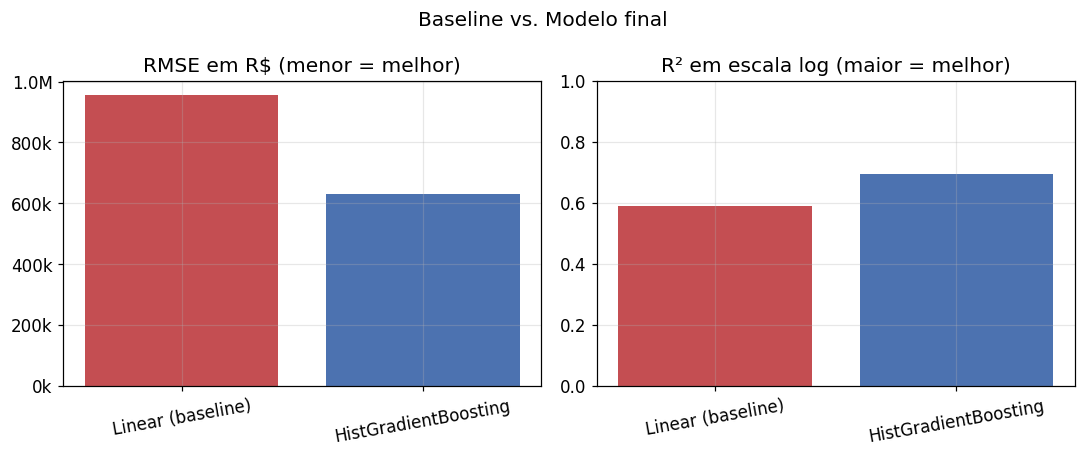

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
modelos = resultados.index.tolist(); cores = ["#C44E52", "#4C72B0"]
axes[0].bar(modelos, resultados["RMSE_R$"], color=cores)
axes[0].set_title("RMSE em R$ (menor = melhor)")
axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_brl))
axes[1].bar(modelos, resultados["R2_log"], color=cores)
axes[1].set_title("R² em escala log (maior = melhor)"); axes[1].set_ylim(0, 1)
for a in axes: a.tick_params(axis="x", labelrotation=10)
fig.suptitle("Baseline vs. Modelo final")
fig.tight_layout(); fig.savefig("grafico4_comparacao_metricas.png"); plt.show()

## Como defender na apresentação
- **Algoritmo final:** `HistGradientBoostingRegressor` — rápido em 1M de linhas e capta
  não-linearidades (depreciação por idade, interação premium × potência) que o linear não
  pega; por isso bate o baseline.
- **Gráfico 1:** pontos na diagonal = boas previsões.
- **Gráfico 2:** resíduos centrados em zero = sem viés.
- **Gráfico 3:** idade, quilometragem, marca premium e potência dominam o preço.
- **Gráfico 4:** prova objetiva de que o modelo final supera o baseline.
